# Monte Carlo Pricing of Rainbow Worst-of Option

This notebook presents an end-to-end workflow for pricing a Rainbow Worst-of option on three equity indices. The project combines market data processing, parameter estimation, correlated GBM simulation, Monte Carlo pricing and finite-difference Greeks.


## 1. Financial instrument

A Rainbow Worst-of option is an exotic multi-asset derivative. Its payoff depends on the worst-performing asset from the basket at maturity.

For a call option:

$$Payoff = max(min(S_1(T), ..., S_n(T)) - K, 0)$$

For a put option:

$$Payoff = max(K - min(S_1(T), ..., S_n(T)), 0)$$

Because the underlying indices have different nominal point levels, this project normalizes all indices to `100` at the valuation date. This makes the payoff depend on relative performance rather than raw index levels.


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT / "src"))

import numpy as np
import pandas as pd

from rainbow_pricer import (
    download_close_prices,
    normalize_to_common_scale,
    estimate_log_return_parameters,
    price_worst_of_option_mc,
    price_convergence,
    compute_delta_fd,
    compute_gamma_fd,
    compute_vega_fd,
    compute_rho_fd,
    compute_theta_fd,
)
from rainbow_pricer.plots import plot_correlation_matrix, plot_normalized_prices, plot_price_convergence


## 2. Configuration

The valuation is based on a fixed date range to make the project reproducible. The option is priced on a normalized index scale with `S_i(0) = 100` and `K = 100`.


In [2]:
VALUATION_DATE = "2026-06-25"
START_DATE = "2023-06-25"

BASE_LEVEL = 100.0
T = 1.0
RISK_FREE_RATE = 0.0537
N_SIMS = 20_000
N_STEPS = 250
SEED = 42


## 3. Market data and normalization

The model downloads daily close prices for S&P 500, EuroStoxx 50 and Nikkei 225. After downloading the data, all indices are normalized to a common valuation-date level of 100.


Downloaded S&P 500 using ticker: ^GSPC
Downloaded EuroStoxx 50 using ticker: ^STOXX50E
Downloaded Nikkei 225 using ticker: ^N225
Original last close levels:


,Last close
S&P 500,7358.220215
EuroStoxx 50,6214.700195
Nikkei 225,69174.968750


Normalized valuation-date levels:


,Scaled S0
S&P 500,100.0
EuroStoxx 50,100.0
Nikkei 225,100.0


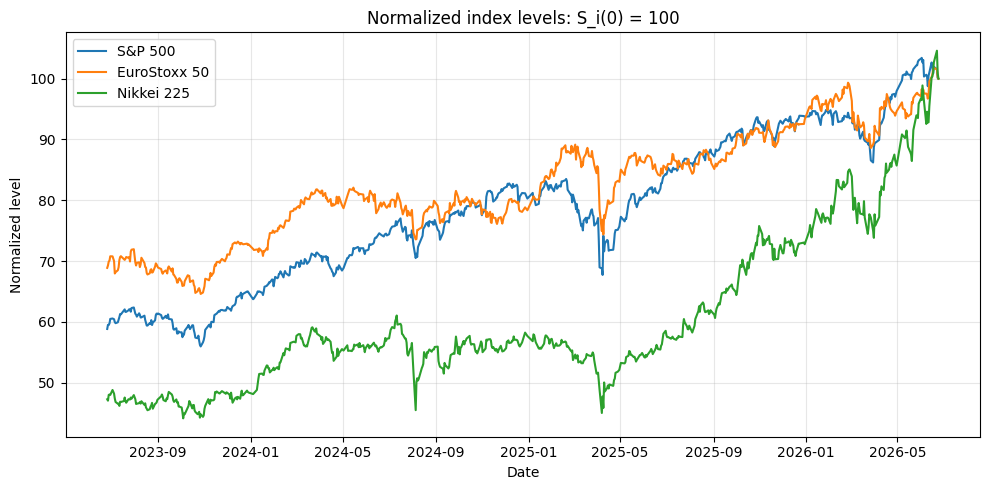

In [3]:
prices = download_close_prices(start_date=START_DATE, end_date=VALUATION_DATE)
prices_scaled = normalize_to_common_scale(prices, base_level=BASE_LEVEL)

print("Original last close levels:")
display(prices.iloc[-1].to_frame("Last close"))

print("Normalized valuation-date levels:")
display(prices_scaled.iloc[-1].to_frame("Scaled S0"))

plot_normalized_prices(prices_scaled)


## 4. Volatility and correlation estimation

Volatilities and correlations are estimated from historical log returns. Log returns are invariant to scaling, so the estimation can be performed on the original index levels.


,Annualized volatility
S&P 500,0.154650
EuroStoxx 50,0.157841
Nikkei 225,0.260301


,S&P 500,EuroStoxx 50,Nikkei 225
S&P 500,1.000000,0.392186,0.148262
EuroStoxx 50,0.392186,1.000000,0.412445
Nikkei 225,0.148262,0.412445,1.000000


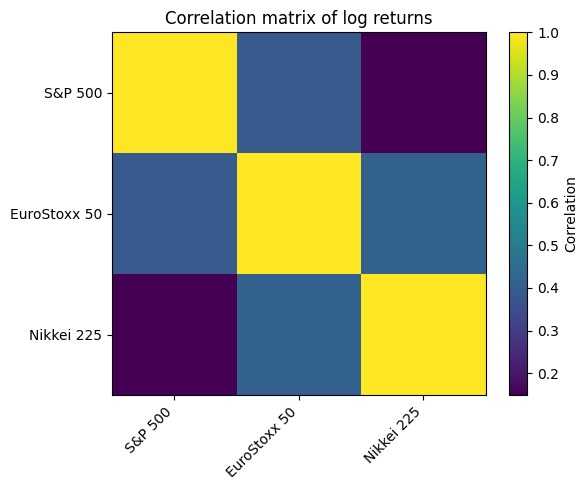

In [4]:
sigma, corr, log_returns = estimate_log_return_parameters(prices)

vol_table = pd.DataFrame({"Annualized volatility": sigma})
display(vol_table)

display(corr)
plot_correlation_matrix(corr)


## 5. Monte Carlo pricing

Correlated GBM paths are simulated using Cholesky decomposition of the covariance matrix. The option value is calculated as the discounted expected payoff.


In [5]:
q = np.zeros(len(sigma))

call_price, call_se = price_worst_of_option_mc(
    prices_common_scale=prices_scaled,
    T=T,
    r=RISK_FREE_RATE,
    q=q,
    sigma=sigma.values,
    corr=corr.values,
    option_type="call",
    n_sims=N_SIMS,
    n_steps=N_STEPS,
    strike=BASE_LEVEL,
    seed=SEED,
)

put_price, put_se = price_worst_of_option_mc(
    prices_common_scale=prices_scaled,
    T=T,
    r=RISK_FREE_RATE,
    q=q,
    sigma=sigma.values,
    corr=corr.values,
    option_type="put",
    n_sims=N_SIMS,
    n_steps=N_STEPS,
    strike=BASE_LEVEL,
    seed=SEED,
)

print(f"Worst-of Call ATM price: {call_price:.4f} | standard error: {call_se:.4f}")
print(f"Worst-of Put  ATM price: {put_price:.4f} | standard error: {put_se:.4f}")


Worst-of Call ATM price: 2.6023 | standard error: 0.0422
Worst-of Put  ATM price: 10.9299 | standard error: 0.0784


## 6. Monte Carlo convergence

The next check shows how the estimated call price changes as the number of simulated paths increases. This is a simple but useful validation step for a Monte Carlo pricer.


,n_sims,price,standard_error
0,1000,2.388230,0.182811
1,2500,2.641006,0.117388
2,5000,2.659506,0.083985
3,10000,2.551403,0.058059
4,20000,2.602251,0.042157
5,50000,2.573785,0.026154


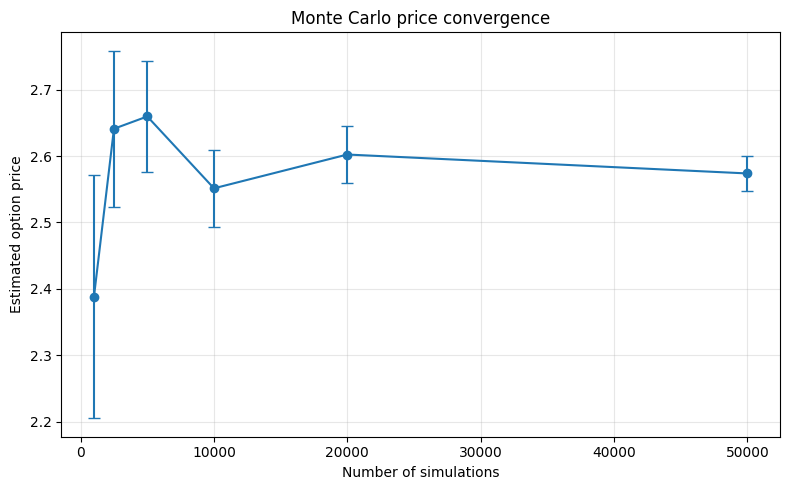

In [6]:
convergence = price_convergence(
    prices_common_scale=prices_scaled,
    T=T,
    r=RISK_FREE_RATE,
    q=q,
    sigma=sigma.values,
    corr=corr.values,
    option_type="call",
    simulation_grid=[1_000, 2_500, 5_000, 10_000, 20_000, 50_000],
    n_steps=N_STEPS,
    strike=BASE_LEVEL,
    seed=SEED,
)

display(convergence)
plot_price_convergence(convergence)


## 7. Greeks with finite differences

Greeks are estimated numerically using central finite differences. The same random seed is used for up/down bumps to reduce Monte Carlo noise.


In [7]:
delta = compute_delta_fd(prices_scaled, T, RISK_FREE_RATE, q, sigma.values, corr.values, seed=SEED)
gamma = compute_gamma_fd(prices_scaled, T, RISK_FREE_RATE, q, sigma.values, corr.values, seed=SEED)
vega = compute_vega_fd(prices_scaled, T, RISK_FREE_RATE, q, sigma.values, corr.values, seed=SEED)
rho = compute_rho_fd(prices_scaled, T, RISK_FREE_RATE, q, sigma.values, corr.values, seed=SEED)
theta = compute_theta_fd(prices_scaled, T, RISK_FREE_RATE, q, sigma.values, corr.values, seed=SEED)

greeks = pd.concat([delta, gamma, vega], axis=1)
display(greeks)

print(f"Rho:   {rho:.6f}")
print(f"Theta: {theta:.6f}")


,Delta,Gamma,Vega
S&P 500,0.122761,0.002511,2.725103
EuroStoxx 50,0.093449,0.001039,2.014838
Nikkei 225,0.073151,0.000812,0.020823


Rho:   26.340251
Theta: 1.786807
